# Convolutional Neural Networks: Application

In this notebook, you will:

- Create a **Mood Classifer (Binary)** using the TF Keras Sequential API
- Build a ConvNet to **Identify Sign Language Digits (Multiclass)** using the TF Keras Functional API
<font color="purple">

**_Definition_**:
- **Sequential API:** Model is a **sequence (linear series)** of layers arranged in order: `Input → Layer 1 → Layer 2 → ... → Output`
- **Functional API:** Model is a **computational graph**, no longer a linear series. We can have:
    - Multiple inputs
    - Multiple outputs
    - Skip connection
    - Merge / split layer...

</font>

**After this assignment we will be able to:**

- Build and train a ConvNet in TensorFlow for a __binary__ classification problem
- Build and train a ConvNet in TensorFlow for a __multiclass__ classification problem
- Explain different use cases for the Sequential and Functional APIs

# Load Library

In [1]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.python.framework import ops

# I. Mood Classifier (Binary)

We'll be using the **Happy House dataset**, which contains images of peoples' faces. Our task will be to build a ConvNet that **determines whether the people in the images are smiling or not** -- because they only get to enter the house if they're smiling!

## 1. Load Data and Split into Train/Test Sets

### 1.1 - Load Data from .h5 File

In [2]:
# ======= DATASETS STRUCTURE =======
train_dataset = h5py.File("datasets/train_happy.h5", "r")
test_dataset = h5py.File("datasets/test_happy.h5", "r")

def print_structure_clean(dataset, title):
    print(f"\n{title}")
    for key in dataset.keys():
        print(f"  • {key}")

print_structure_clean(train_dataset, "Train Set Structure")
print_structure_clean(test_dataset, "Test Set Structure")


Train Set Structure
  • list_classes
  • train_set_x
  • train_set_y

Test Set Structure
  • list_classes
  • test_set_x
  • test_set_y


In [3]:
# ======= TRAINING SET =======
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("train_set_y_orig shape:", train_set_y_orig.shape)

train_set_x_orig shape: (600, 64, 64, 3)
train_set_y_orig shape: (600,)


In [4]:
# ======= TEST SET =======
test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])
print("test_set_x_orig shape:", test_set_x_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

test_set_x_orig shape: (150, 64, 64, 3)
test_set_y_orig shape: (150,)


In [5]:
# ======= CLASSES =======
list_classes = np.array(train_dataset["list_classes"][:])
print("Classes shape:", list_classes.shape)

Classes shape: (2,)


### 1.2 - Convert all 1D -> 2D Array

Just **apply** in **Binary classification (0/1)**. Because of:
- **Easier for compute Loss**
- **Match with Output model**

**_Note:_** We do **NOT need** to **convert classes** because it does **NOT participate** in the **calculation** nor **input** for the **model**.

In [6]:
train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
print("train_set_y_orig shape:", train_set_y_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

train_set_y_orig shape: (1, 600)
test_set_y_orig shape: (1, 150)


### 1.3 - Split Data

We can display the images contained in the dataset.

Images are **64x64** pixels in RGB format (3 channels):
- **X_train/X_test shape**: `(batch_size, height, width, channels)`
- **Y_train/Y_test shape**: `(batch_size, 1)`
- **Classes shape**: `(#classes,)`

In [7]:
# Normalize image vectors
X_train = train_set_x_orig/255.
X_test = test_set_x_orig/255.

# Reshape
Y_train = train_set_y_orig.T
Y_test = test_set_y_orig.T

# Classes
classes = list_classes

print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))
print ("Classes shape: " + str(classes.shape))

Number of training examples = 600
Number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)
Classes shape: (2,)


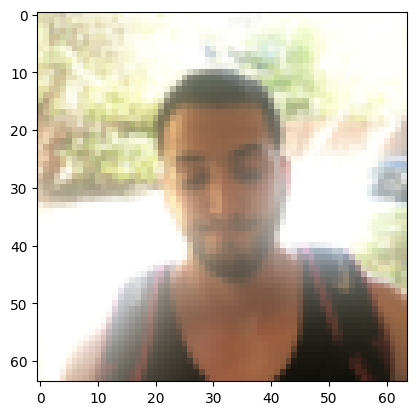

In [8]:
index = 124
plt.imshow(X_train[index]) #display sample training image
plt.show()